# Mini-Project 1: Rock vs Mine Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

SONAR dataset classification using Logistic Regression.

Main goals:

- Understand the complete binary classification workflow.
- Explore a small high-dimensional dataset (208 samples, 60 features).
- Compare training and test performance.
- Investigate the effect of regularisation.

---

## Setup and Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

print('All imports successful')

All imports successful


## Load the Dataset

In [5]:
# The SONAR dataset: 208 samples, 60 numeric features + 1 label column
# Each feature is the energy of a sonar signal at a particular frequency
# Label: R = Rock, M = Mine (metal cylinder)

url = "https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/main/dataset/sonar%20data.csv"

# Column names: 60 numeric features (unnamed) + 'label'
df = pd.read_csv(url, header=None)
df.columns = [f'f{i+1}' for i in range(60)] + ['label']

print('Shape:', df.shape)
print('\nFirst row (truncated to first 10 features + label):')
display_cols = [f'f{i+1}' for i in range(10)] + ['label']
print(df[display_cols].head(3).to_string())

Shape: (208, 61)

First row (truncated to first 10 features + label):
       f1      f2      f3      f4      f5      f6      f7      f8      f9     f10 label
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  0.2111     R
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337  0.2872     R
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598  0.6194     R


## Exploratory Data Analysis

In [6]:
# Class distribution
print('=== Class Distribution ===')
class_counts = df['label'].value_counts()
print(class_counts)
print(f'\nRock (R): {class_counts["R"]} samples ({class_counts["R"]/len(df)*100:.1f}%)')
print(f'Mine (M): {class_counts["M"]} samples ({class_counts["M"]/len(df)*100:.1f}%)')
print('\nConclusion: Classes are fairly balanced — accuracy is a reliable metric here.')

=== Class Distribution ===
label
M    111
R     97
Name: count, dtype: int64

Rock (R): 97 samples (46.6%)
Mine (M): 111 samples (53.4%)

Conclusion: Classes are fairly balanced — accuracy is a reliable metric here.


In [7]:
# Statistical summary of numeric features
print('=== Feature Statistics ===')
stats = df.drop('label', axis=1).describe().round(4)
print(stats[['f1', 'f10', 'f30', 'f60']].to_string())  # sample of 4 features

print('\n=== Missing Values ===')
missing = df.isnull().sum().sum()
print(f'Total missing values: {missing}  (none — dataset is complete)')

=== Feature Statistics ===
             f1       f10       f30       f60
count  208.0000  208.0000  208.0000  208.0000
mean     0.0292    0.2083    0.5809    0.0065
std      0.0230    0.1344    0.2207    0.0050
min      0.0015    0.0113    0.0613    0.0006
25%      0.0134    0.1113    0.4114    0.0031
50%      0.0228    0.1824    0.6072    0.0053
75%      0.0356    0.2687    0.7352    0.0085
max      0.1371    0.7106    1.0000    0.0439

=== Missing Values ===
Total missing values: 0  (none — dataset is complete)


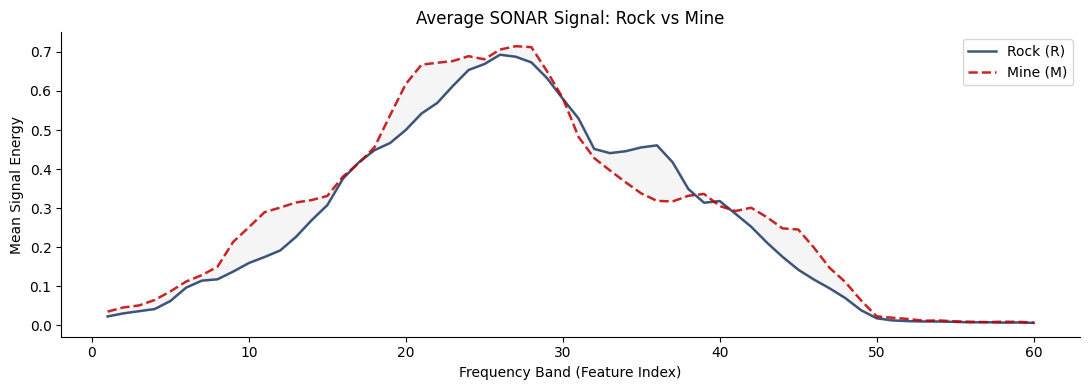

In [8]:
# Visualise mean signal by class — what does a rock vs mine signal look like?
rock_mean = df[df['label'] == 'R'].drop('label', axis=1).mean()
mine_mean = df[df['label'] == 'M'].drop('label', axis=1).mean()

fig, ax = plt.subplots(figsize=(11, 4))
x = range(1, 61)
ax.plot(x, rock_mean.values, color='#1F3864', lw=1.8, label='Rock (R)', alpha=0.85)
ax.plot(x, mine_mean.values, color='#C00000', lw=1.8, label='Mine (M)', linestyle='--', alpha=0.85)
ax.fill_between(x, rock_mean.values, mine_mean.values, alpha=0.08, color='gray')
ax.set_xlabel('Frequency Band (Feature Index)')
ax.set_ylabel('Mean Signal Energy')
ax.set_title('Average SONAR Signal: Rock vs Mine')
ax.legend()
plt.tight_layout()
plt.show()

The two classes have different signal shapes, especially around bands 10–30.

These differences are what the model will learn to detect.

**Observation:** I expected the two classes to look very different, but the average signal profiles overlap quite a bit. This helped me understand why classification is not straightforward on this dataset.

## Data Preparation

In [9]:
# Separate features (X) and label (y)
X = df.drop('label', axis=1).values      # shape: (208, 60)
y = df['label'].values                    # shape: (208,)

print(f'X shape: {X.shape}  (208 samples × 60 features)')
print(f'y shape: {y.shape}')
print(f'y unique values: {np.unique(y)}')

X shape: (208, 60)  (208 samples × 60 features)
y shape: (208,)
y unique values: ['M' 'R']


**Observation:** With only 208 samples and 60 features, this dataset is much smaller than I expected. It made me pay more attention to overfitting and the difference between training and test accuracy.

In [10]:
# Train-test split: 90% train, 10% test
# stratify=y ensures both splits have the same R/M ratio
# Note: 90/10 is used here following the course notebook;
# 80/20 is more common in practice. With only 208 samples,
# either gives a small test set — cross-validation would be more rigorous.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=1, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'\nTrain class distribution: R={np.sum(y_train=="R")}, M={np.sum(y_train=="M")}')
print(f'Test class distribution : R={np.sum(y_test=="R")},  M={np.sum(y_test=="M")}')

Training set : 187 samples
Test set     : 21 samples

Train class distribution: R=87, M=100
Test class distribution : R=10,  M=11


## Model Training

In [11]:
# Logistic Regression — binary classification model
# max_iter=1000 to ensure convergence (default 100 can warn on this dataset)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print('Model trained successfully.')
print(f'\nNumber of features: {model.coef_.shape[1]}')
print(f'Classes            : {model.classes_}')

Model trained successfully.

Number of features: 60
Classes            : ['M' 'R']


## Evaluation

In [12]:
# Training accuracy — how well the model fits training data
train_predictions = model.predict(X_train)
train_accuracy    = accuracy_score(y_train, train_predictions)

# Test accuracy — how well the model generalises to unseen data
test_predictions = model.predict(X_test)
test_accuracy    = accuracy_score(y_test, test_predictions)

print(f'Training Accuracy : {train_accuracy:.4f}  ({train_accuracy:.1%})')
print(f'Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy:.1%})')
print(f'\nGap (train - test): {(train_accuracy - test_accuracy):.4f}')

if train_accuracy - test_accuracy > 0.05:
    print('Note: Gap > 5% — mild overfitting. Model fits training data better than test data.')
else:
    print('Gap is small — model generalises reasonably well to unseen data.')

Training Accuracy : 0.8342  (83.4%)
Test Accuracy     : 0.7619  (76.2%)

Gap (train - test): 0.0723
Note: Gap > 5% — mild overfitting. Model fits training data better than test data.


In [13]:
# Detailed classification report
print('=== Classification Report (Test Set) ===')
print(classification_report(y_test, test_predictions, target_names=['Mine (M)', 'Rock (R)']))

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

    Mine (M)       0.75      0.82      0.78        11
    Rock (R)       0.78      0.70      0.74        10

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.76      0.76      0.76        21



**Observation:**
Looking at the classification report was more informative than accuracy alone. Two models can have similar accuracy while making very different types of mistakes.

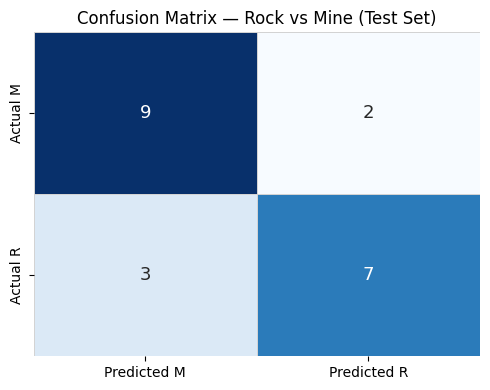

In [14]:
# Confusion matrix visualisation
cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted M', 'Predicted R'],
            yticklabels=['Actual M', 'Actual R'],
            linewidths=0.5, linecolor='lightgray', cbar=False,
            annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Rock vs Mine (Test Set)')
plt.tight_layout()
plt.show()

## Tracing a Single Prediction End-to-End

In [15]:
# Take one sample from the test set and trace what happens inside the model

sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)   # shape (1, 60)
true_label = y_test[sample_idx]

# Step 1: Linear combination z = X @ w + b
z = np.dot(sample, model.coef_.T) + model.intercept_

# Step 2: Sigmoid probability
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

prob = sigmoid(z)

# Step 3: Class prediction
prediction = model.predict(sample)[0]
probabilities = model.predict_proba(sample)[0]

print(f'Sample index           : {sample_idx}')
print(f'True label             : {true_label}')
print(f'Linear combination z   : {z[0][0]:.4f}')
print(f'P(Mine | x)            : {probabilities[0]:.4f}')
print(f'P(Rock | x)            : {probabilities[1]:.4f}')
print(f'Predicted class        : {prediction}')
print(f'Prediction correct?    : {prediction == true_label}')

Sample index           : 0
True label             : M
Linear combination z   : -0.4429
P(Mine | x)            : 0.6089
P(Rock | x)            : 0.3911
Predicted class        : M
Prediction correct?    : True


**Observation:** Tracing a single prediction helped me connect the mathematical equations of Logistic Regression with the actual outputs produced by the model.

## Effect of Regularisation — A Quick Investigation

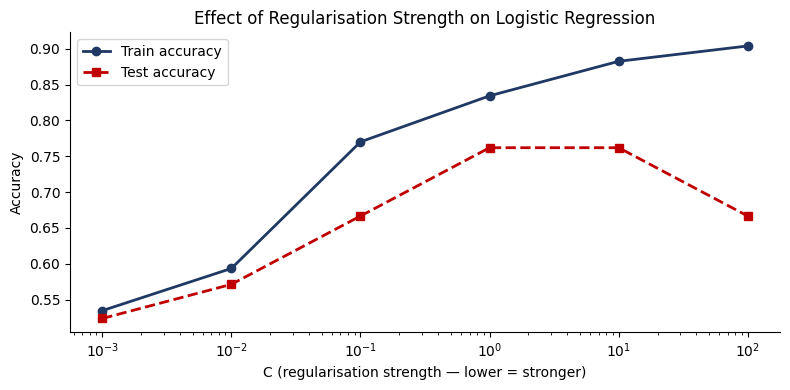


C values and accuracies:
  C= 0.001  train=0.535  test=0.524  gap=0.011
  C= 0.010  train=0.594  test=0.571  gap=0.022
  C= 0.100  train=0.770  test=0.667  gap=0.103
  C= 1.000  train=0.834  test=0.762  gap=0.072
  C=10.000  train=0.882  test=0.762  gap=0.120
  C=100.000  train=0.904  test=0.667  gap=0.237


In [16]:
# The C parameter in sklearn's LogisticRegression controls regularisation strength
# Smaller C = stronger regularisation = more penalty on large weights
# This is a way to reduce overfitting

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_accs, test_accs = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, train_accs, 'o-', color='#1F3864', lw=2, label='Train accuracy')
ax.semilogx(C_values, test_accs,  's--', color='#C00000', lw=2, label='Test accuracy')
ax.set_xlabel('C (regularisation strength — lower = stronger)')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of Regularisation Strength on Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

print('\nC values and accuracies:')
for C, tr, te in zip(C_values, train_accs, test_accs):
    print(f'  C={C:6.3f}  train={tr:.3f}  test={te:.3f}  gap={tr-te:.3f}')

**Observation:** This experiment made regularisation much easier to understand. As the model became more flexible, training accuracy improved, but the gap between training and test performance also increased.

## Key Takeaways

- Logistic Regression can perform reasonably well even on a small high-dimensional dataset.
- Looking only at accuracy can hide important model behaviour.
- Train and test accuracy should always be compared to check for overfitting.
- Regularisation has a noticeable effect on generalisation performance.
- Understanding a single prediction helped me connect the implementation with the underlying mathematics.

### Personal Reflection

This was my first complete Machine Learning project from data loading to evaluation. Before working on it, concepts such as train-test splitting, classification metrics, and regularisation felt disconnected. Seeing them together in one workflow made the overall process much clearer.